In [1]:
import pandas as pd
import ast
import numpy as np
import matplotlib.pyplot as plt

In [2]:
forestdf = pd.read_csv('../data/forest_measurements.csv')

In [3]:
forestdf

,chunk_id,paper_id,name,context,measurement,measurement_id,value
0,10,0,Myanmar,| | Based on compilations of harv...,Total carbon sequestered per annum,8,2377
1,7,0,Colombia,| | Based on compilations of harv...,Total carbon sequestered per annum,10,117
2,7,0,Congo,| | Based on compilations of harv...,Total carbon sequestered per annum,16,5472
3,0,0,Central,Environ. Res. Lett. 2 (2007) 045023 (13pp)\n\n...,Total carbon sequestered per annum,18,1
4,7,0,Brunei,| | Based on compilations of harv...,Total carbon sequestered per annum,28,40
5,10,0,PNG,| | Based on compilations of harv...,Total carbon sequestered per annum,30,4154
6,10,0,Vietnam,| | Based on compilations of harv...,Total carbon sequestered per annum,42,774
7,7,0,El Salvador,| | Based on compilations of harv...,Total carbon sequestered per annum,44,105
8,10,0,Philippines,| | Based on compilations of harv...,Total carbon sequestered per annum,60,765
9,7,0,Bangladesh,| | Based on compilations of harv...,Total carbon sequestered per annum,62,65


In [16]:
idx = 0
row = forestdf.iloc[idx, :]
extracted_value = row.value
measurement_id = row.measurement_id
context_scores = np.load(f"../data/scores/context_{measurement_id}.npz")['context_scores'][0]
parametric_scores = np.load(f"../data/scores/parametric_{measurement_id}.npz")['parametric_scores']

print(f"Extracted Value:\n {extracted_value}")

Extracted Value:
 2377


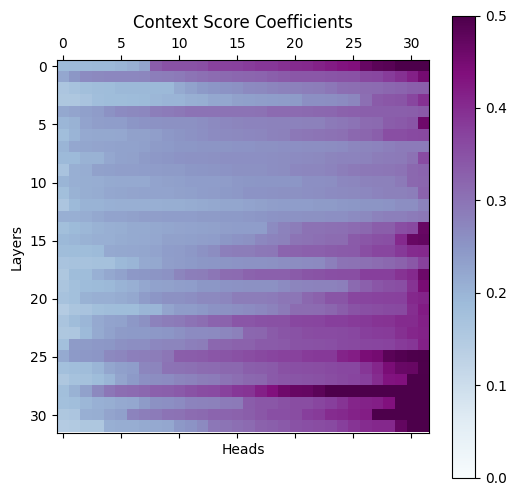

In [17]:
fig,ax = plt.subplots(figsize=(6,6), dpi = 100)
pos = ax.matshow(np.sort(context_scores, axis = 1), cmap='BuPu', vmin = 0.0, vmax = 0.50)
ax.set_ylabel('Layers')
ax.set_xlabel('Heads')
ax.set_title(f'Context Score Coefficients')
fig.colorbar(pos, ax=ax)
plt.savefig('../data/figures/context_truth.png')